# Test 4: LTV 6-го місяця на 1 користувача

**Завдання.** Є дані по проєкту X: `rd` — дата реєстрації, `customer_id` — ID користувача, `TD` — дата транзакції, `revenue_usd` — дохід від користувача на момент TD.
1. Оцінити LTV 6-го місяця на 1 користувача.
2. Побудувати криву LTV за результатами п.1.

In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [80]:
df = pd.read_csv("../data/MainFile - Test_4.csv", na_values=['(null)'], decimal=',')
df.head()

,rd,customer_id,TD,revenue_usd
0,11/24/2017,981511946,5/22/2018,4.621145
1,11/24/2017,981511946,6/8/2019,4.622467
2,11/24/2017,981511946,5/14/2018,0.000000
3,11/24/2017,981511949,NaN,NaN
4,11/24/2017,981511950,NaN,NaN


In [81]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4287 entries, 0 to 4286
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   rd           4287 non-null   str    
 1   customer_id  4287 non-null   int64  
 2   TD           1250 non-null   str    
 3   revenue_usd  1250 non-null   float64
dtypes: float64(1), int64(1), str(2)
memory usage: 134.1 KB


In [82]:
df['rd'] = pd.to_datetime(df['rd'], format='%m/%d/%Y')
df['TD'] = pd.to_datetime(df['TD'], format='%m/%d/%Y')
df['revenue_usd'] = pd.to_numeric(df['revenue_usd'], errors='coerce')

print(df.shape)
print(df.dtypes)
df.head()

(4287, 4)
rd             datetime64[us]
customer_id             int64
TD             datetime64[us]
revenue_usd           float64
dtype: object


,rd,customer_id,TD,revenue_usd
0,2017-11-24,981511946,2018-05-22,4.621145
1,2017-11-24,981511946,2019-06-08,4.622467
2,2017-11-24,981511946,2018-05-14,0.000000
3,2017-11-24,981511949,NaT,NaN
4,2017-11-24,981511950,NaT,NaN


In [83]:
print("Пропуски:\n", df.isna().sum(), "\n")
print("Унікальних користувачів:", df['customer_id'].nunique())
print("Діапазон rd:", df['rd'].min().date(), "-", df['rd'].max().date())
print("Діапазон TD:", df['TD'].min().date(), "-", df['TD'].max().date())
print("Дублікати рядків:", df.duplicated().sum())
print("Користувачів із rd, що відрізняється між рядками:", (df.groupby('customer_id')['rd'].nunique() > 1).sum())
print("Транзакцій раніше реєстрації (TD < rd):", (df['TD'] < df['rd']).sum())
print("Від'ємних доходів:", (df['revenue_usd'] < 0).sum())

Пропуски:
 rd                0
customer_id       0
TD             3037
revenue_usd    3037
dtype: int64 

Унікальних користувачів: 3576
Діапазон rd: 2017-11-24 - 2019-05-11
Діапазон TD: 2017-12-23 - 2019-11-02
Дублікати рядків: 0
Користувачів із rd, що відрізняється між рядками: 0
Транзакцій раніше реєстрації (TD < rd): 0
Від'ємних доходів: 0


**Що видно:**
- `TD` і `revenue_usd` порожні одночасно — це користувачі, які зареєструвались, але **жодної операції не мали**. Їх треба лишити в аналізі: LTV рахується на *кожного зареєстрованого*, а не лише на платників.
- У кожного користувача одна дата реєстрації, транзакцій до реєстрації немає, від'ємних сум немає — дані чисті.

In [91]:
tx = df.dropna(subset=['TD']).sort_values(['customer_id', 'TD'])

print("Найчастіші значення revenue_usd:")
print(tx['revenue_usd'].round(4).value_counts().head(6), "\n")

example = tx['customer_id'].value_counts().index[0]
tx[tx['customer_id'] == example][['TD', 'revenue_usd']].head(10)

Найчастіші значення revenue_usd:
revenue_usd
4.6225    533
0.0000    493
4.6211    102
7.3978     17
1.0749     11
3.0793     11
Name: count, dtype: int64 



,TD,revenue_usd
258,2018-02-09,7.396476
270,2018-05-18,0.000000
287,2018-05-25,4.621145
291,2018-06-27,4.621145
248,2018-08-09,4.621145
286,2018-11-03,4.622467
297,2018-11-10,4.622467
299,2018-11-17,4.622467
251,2018-11-24,4.622467
261,2018-12-02,4.622467


## База користувачів і дата вивантаження

- `users` — один рядок на користувача (знаменник LTV).
- Дата вивантаження — найпізніша `TD` у даних. Щоб не занижувати LTV6 «незрілими» користувачами, беремо лише тих, у кого від реєстрації минуло **повні 6 місяців**: `rd ≤ вивантаження − 6 міс`.

In [85]:
users = df.groupby('customer_id', as_index=False)['rd'].first()

cutoff = df['TD'].max()
mature_limit = cutoff - pd.DateOffset(months=6)
base = users[users['rd'] <= mature_limit]

print("Дата вивантаження:", cutoff.date())
print("Гранична дата реєстрації:", mature_limit.date())
print(f"Користувачів усього: {len(users)}, у розрахунку LTV6: {len(base)} (виключено {len(users)-len(base)} свіжих)")

Дата вивантаження: 2019-11-02
Гранична дата реєстрації: 2019-05-02
Користувачів усього: 3576, у розрахунку LTV6: 3517 (виключено 59 свіжих)


## Кумулятивний дохід по місяцях життя

Для кожного місяця `m` (0…6) беремо операції з `TD ≤ rd + m календарних місяців` і сумуємо. **Усі точки кривої рахуємо на одній і тій самій вибірці** (`base`), інакше склад користувачів мінявся б між точками і крива могла б «просідати» без реальної причини.

In [86]:
tx_base = tx.merge(base, on=['customer_id', 'rd'], how='inner')
n_users = len(base)

rows = []
for m in range(0, 7):
    limit = tx_base['rd'] + pd.DateOffset(months=m)
    in_window = tx_base[tx_base['TD'] <= limit]
    revenue = in_window['revenue_usd'].sum()
    payers = in_window.loc[in_window['revenue_usd'] > 0, 'customer_id'].nunique()
    rows.append({'month': m, 'revenue_usd': revenue, 'ltv_per_user': revenue / n_users,
                 'payers': payers, 'payer_share': payers / n_users})

ltv = pd.DataFrame(rows).set_index('month')
ltv['increment'] = ltv['ltv_per_user'].diff().fillna(ltv['ltv_per_user'])
ltv

,revenue_usd,ltv_per_user,payers,payer_share,increment
month,,,,,
0,210.004405,0.059711,40,0.011373,0.059711
1,1403.369440,0.399025,180,0.051180,0.339313
2,1952.940107,0.555286,193,0.054876,0.156261
3,2317.931737,0.659065,198,0.056298,0.103779
4,2533.332178,0.720311,199,0.056582,0.061246
5,2663.681957,0.757373,200,0.056867,0.037063
6,2821.150239,0.802147,204,0.058004,0.044773


In [87]:
ltv6 = ltv.loc[6, 'ltv_per_user']
payers6 = int(ltv.loc[6, 'payers'])

print(f"LTV6 на 1 зареєстрованого користувача: ${ltv6:.3f}")
print(f"Конверсія в платника за 6 міс: {ltv.loc[6, 'payer_share']:.1%}  ({payers6} з {n_users})")
print(f"LTV6 на 1 платника: ${ltv.loc[6, 'revenue_usd'] / payers6:.2f}")

LTV6 на 1 зареєстрованого користувача: $0.802
Конверсія в платника за 6 міс: 5.8%  (204 з 3517)
LTV6 на 1 платника: $13.83


# Відповідь на п.2 — крива LTV

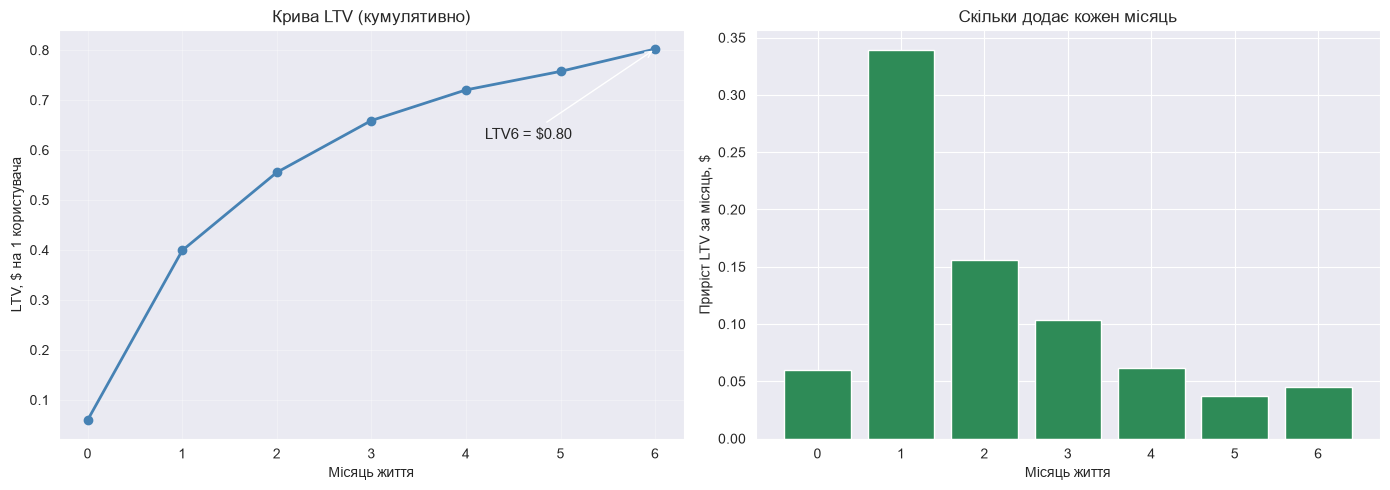

In [88]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(ltv.index, ltv['ltv_per_user'], marker='o', linewidth=2, color='steelblue')
ax.annotate(f"LTV6 = ${ltv6:.2f}", xy=(6, ltv6), xytext=(4.2, ltv6 - 0.18),
            arrowprops=dict(arrowstyle='->'), fontsize=11)
ax.set_xlabel('Місяць життя')
ax.set_ylabel('LTV, $ на 1 користувача')
ax.set_title('Крива LTV (кумулятивно)')
ax.set_xticks(range(0, 7))
ax.grid(alpha=0.3)

ax = axes[1]
ax.bar(ltv.index, ltv['increment'], color='seagreen')
ax.set_xlabel('Місяць життя')
ax.set_ylabel('Приріст LTV за місяць, $')
ax.set_title('Скільки додає кожен місяць')
ax.set_xticks(range(0, 7))

plt.tight_layout()
plt.show()

## Перевірка стабільності: LTV6 за кварталом реєстрації

Одне середнє може ховати різницю між когортами. Рахуємо LTV6 окремо по кварталах реєстрації (для тих самих зрілих користувачів).

In [89]:
limit6 = tx_base['rd'] + pd.DateOffset(months=6)
rev6 = (tx_base[tx_base['TD'] <= limit6]
        .groupby('customer_id')['revenue_usd'].sum()
        .rename('rev6'))

cohort = base.merge(rev6, on='customer_id', how='left').fillna({'rev6': 0})
cohort['quarter'] = cohort['rd'].dt.to_period('Q')

by_q = cohort.groupby('quarter').agg(
    users=('customer_id', 'count'),
    revenue=('rev6', 'sum'),
    payers=('rev6', lambda s: (s > 0).sum()),
)
by_q['ltv6'] = by_q['revenue'] / by_q['users']
by_q.loc['Разом'] = [by_q['users'].sum(), by_q['revenue'].sum(), by_q['payers'].sum(),
                     by_q['revenue'].sum() / by_q['users'].sum()]
by_q

,users,revenue,payers,ltv6
quarter,,,,
2017Q4,92.0,17.550661,3.0,0.190768
2018Q1,324.0,54.502203,7.0,0.168217
2018Q2,392.0,156.656828,15.0,0.399635
2018Q3,619.0,549.101762,51.0,0.887079
2018Q4,1078.0,1266.263877,64.0,1.174642
2019Q1,724.0,610.343404,49.0,0.843016
2019Q2,288.0,166.731505,15.0,0.578929
Разом,3517.0,2821.150239,204.0,0.802147


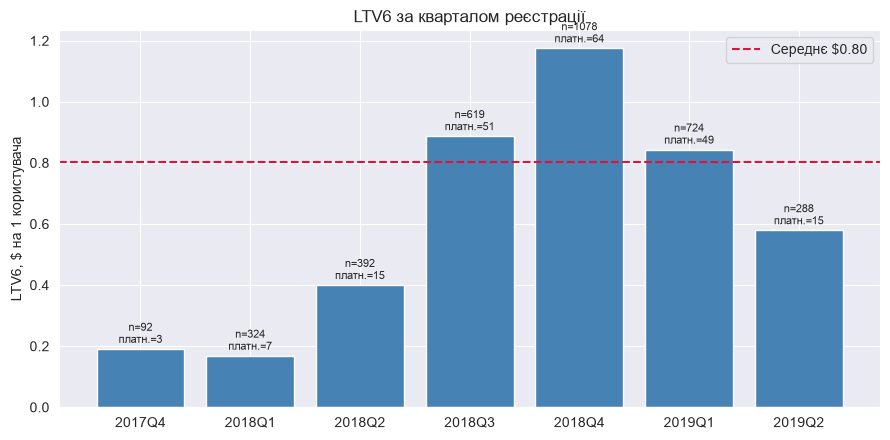

In [90]:
q = by_q.drop('Разом')
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(q.index.astype(str), q['ltv6'], color='steelblue')
ax.axhline(ltv6, color='crimson', linestyle='--', label=f'Середнє ${ltv6:.2f}')
for i, (u, p) in enumerate(zip(q['users'], q['payers'])):
    ax.text(i, q['ltv6'].iloc[i] + 0.02, f'n={int(u)}\nплатн.={int(p)}', ha='center', fontsize=8)
ax.set_ylabel('LTV6, $ на 1 користувача')
ax.set_title('LTV6 за кварталом реєстрації')
ax.legend()
plt.tight_layout()
plt.show()

## Висновки

| | |
|---|---|
| **LTV 6-го місяця** | ≈ $0,80 на 1 зареєстрованого користувача(≈ $13,8 на 1 платника) |
| Конверсія в платника за 6 міс | ≈ 5,8% |
| Форма кривої | різкий старт (перший місяць ≈ 50% LTV6), далі плато |

**Що варто враховувати:**
1. **Тлумачення `revenue_usd`.** Прийнято, що це дохід за операцію (а не наростаючий підсумок) — це підтверджується повторюваними тижневими сумами. Слід уточнити у замовника.
2. **Користувачі без операцій** включені в знаменник — це і є «на 1 користувача». Якщо потрібен LTV лише платників, це 13,8.
3. **Когорти дуже різняться:** від ≈ 0,17 (2018Q1) до ≈ 1,17 (2018Q4). Загальне $0,80 — зважене середнє, залежне від міксу когорт; у ранніх когорт платників лише 3–15, тож їхні оцінки нестабільні. Для планування краще брати LTV свіжих когорт, а не середнє за весь період.